In [ ]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt


#### Step 1: Load the Data



In [ ]:
# Load the datasets
df = pd.read_csv('https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/interactions_train.csv')
books = pd.read_csv("https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/items.csv")
links = pd.read_csv("https://raw.githubusercontent.com/sandrotissi/book-recommender/0ca2f3f0ea5d72dd53b107ed15ea40401a48e74b/sample_submission.csv")


Read Count Summary (1 to 10):
read_count
1     53627
2      5642
3      2196
4      1125
5       565
6       289
7       131
8        90
9        69
10       54
Name: count, dtype: int64


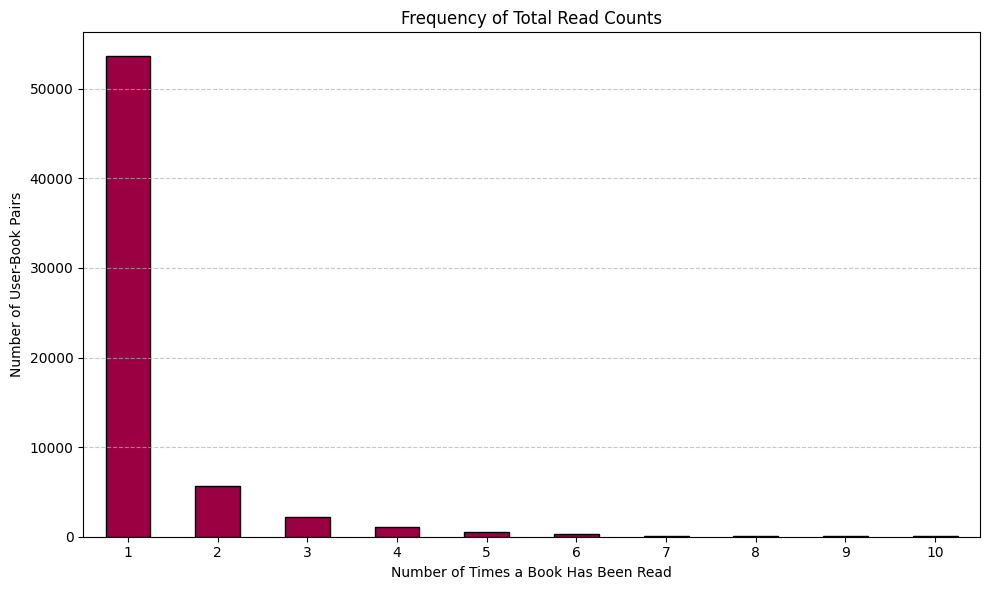

In [ ]:

# 2. Count total interactions per user-book pair
interaction_counts = df.groupby(['u', 'i']).size().reset_index(name='read_count')

# 3. Calculate the frequency of each read count (1, 2, 3...)
read_distribution = interaction_counts['read_count'].value_counts().sort_index()

# 4. Limit the distribution to 1 through 10 for the graph
read_distribution_limited = read_distribution.loc[1:10]

# 5. Visualize the distribution
plt.figure(figsize=(10, 6))
read_distribution_limited.plot(kind='bar', color='#9b0142', edgecolor='black')
plt.title('Frequency of Total Read Counts')
plt.xlabel('Number of Times a Book Has Been Read')
plt.ylabel('Number of User-Book Pairs')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('read_distribution_1_to_10.png')

# 6. Display the data summary
print("Read Count Summary (1 to 10):")
print(read_distribution_limited)

Unique Users: 366
Unique Books: 384


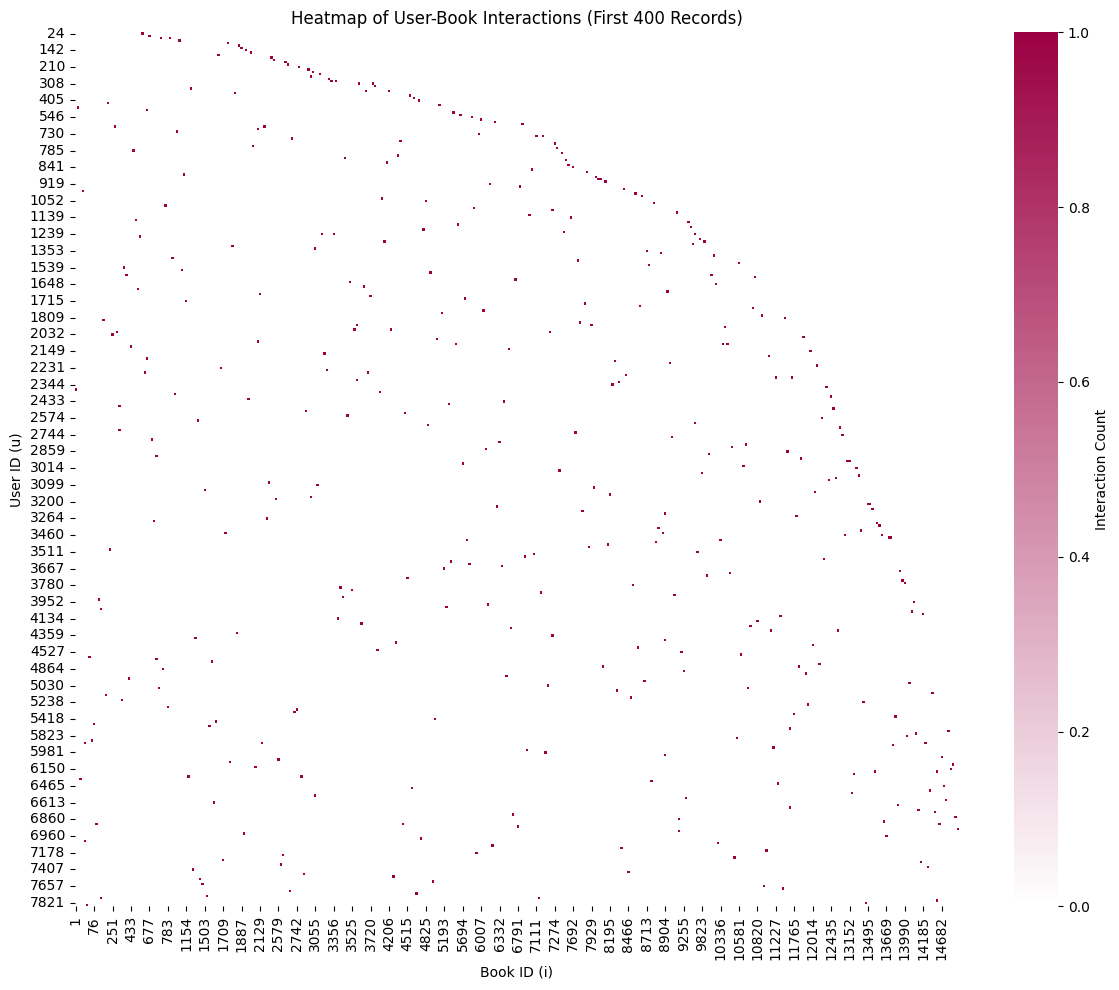

In [ ]:
import matplotlib.colors

# 2. Take the first 400 interactions as requested
df_subset = df.head(400)

# 3. Create a pivot table: Rows = Users (u), Columns = Books (i)
# We fill with 0 where no interaction exists
heatmap_data = df_subset.pivot_table(index='u', columns='i', aggfunc='size', fill_value=0)

# 4. Set up the visualization
# Using subplots to control size as the matrix is large
f, ax = plt.subplots(figsize=(12, 10))

# Create a custom colormap that transitions from white to #9b0142
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom_white_to_color", ["white", "#9b0142"], N=256)

# 5. Generate the heatmap
# We use a sequential color map to highlight interactions, with 0 as white
sns.heatmap(heatmap_data, cmap=custom_cmap, cbar_kws={"label": 'Interaction Count'}, ax=ax)

ax.set_title('Heatmap of User-Book Interactions (First 400 Records)')
ax.set_xlabel('Book ID (i)')
ax.set_ylabel('User ID (u)')

# 6. Save the result
plt.tight_layout()
plt.savefig('interactions_heatmap_2000.png')

# Displaying the sparsity stats
print(f"Unique Users: {heatmap_data.index.nunique()}")
print(f"Unique Books: {heatmap_data.columns.nunique()}")